In [73]:
%pip install tensorflow
%pip install tensorflow-datasets
%pip install matplotlib
%pip install importlib_resources
%pip install pydub
%pip install torchaudio
%pip install torch
%pip install torchcodec

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 47.5 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [106]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import importlib_resources


(ds_train, ds_test), info = tfds.load(
    "speech_commands",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
    data_dir="./tfds"
)


labels = info.features["label"].names
print(labels)

['down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes', '_silence_', '_unknown_']


Les dataset sont conçus comme des stream. 

In [2]:
import numpy as np

#Ici on itére dans le ds_train on récupere des couples audio / label
for audio, label in ds_train.take(1): break
print(audio.shape, labels[label])

I0000 00:00:1778849573.774095    9338 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


(16000,) off


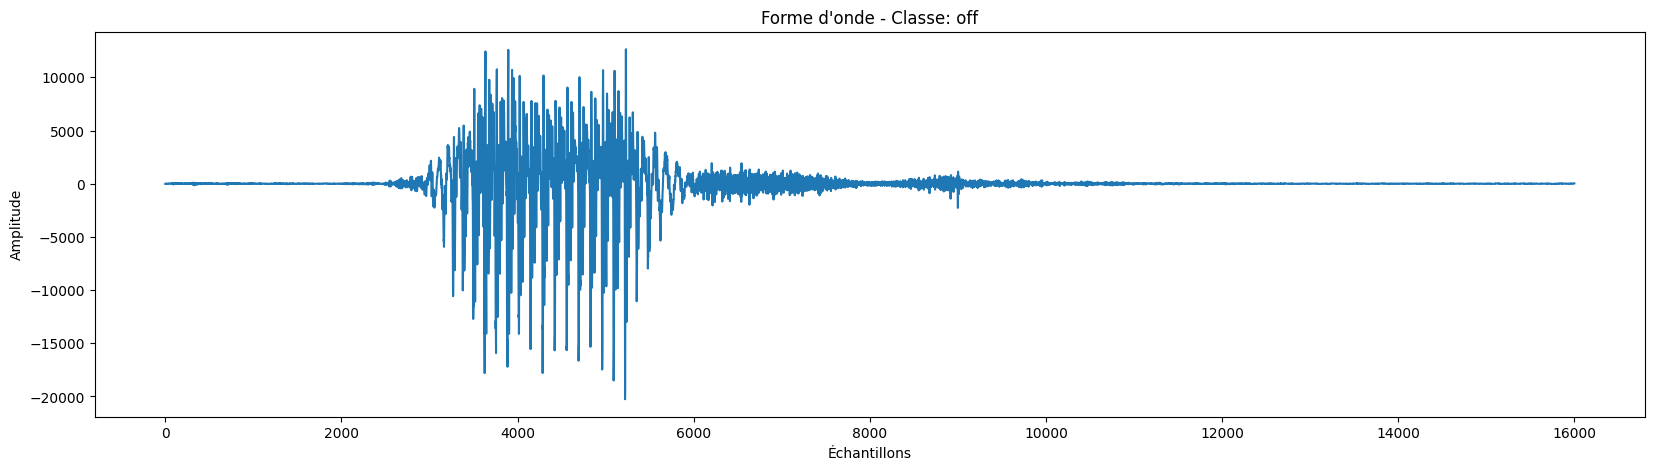

In [3]:
plt.figure(figsize=(20, 5))
plt.plot(audio)
plt.title(f"Forme d'onde - Classe: {labels[label]}")
plt.xlabel("Échantillons")
plt.ylabel("Amplitude")
plt.show()

Le MelSpectrogram n'est pas la même chose qu'un spectrogram classique.

In [5]:
layer = tf.keras.layers.MelSpectrogram()

In [7]:
spectrogram = layer(audio)

In [21]:
spectrogram.numpy().T.shape

(32, 128)

Text(0.5, 1.0, 'Mel Spectrogram')

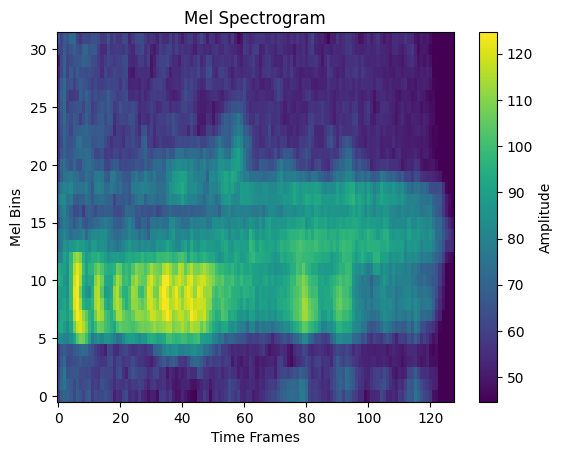

In [15]:
plt.imshow(spectrogram.numpy().T, aspect="auto", origin="lower")
plt.colorbar(label='Amplitude')
plt.xlabel('Time Frames')
plt.ylabel('Mel Bins')
plt.title('Mel Spectrogram')

(array([[1.02489955e-02, 7.54647328e-02, 1.71798447e-01, ...,
         1.12003783e-02, 3.84935571e-01, 1.65756502e-01],
        [2.07165263e-02, 1.02450389e-01, 1.04748431e+00, ...,
         6.39861226e-02, 1.31208650e+00, 4.07519262e-01],
        [4.09384138e-02, 9.53622013e-02, 3.16385132e-01, ...,
         1.26525819e-01, 1.04480276e+00, 3.96169474e-01],
        ...,
        [4.62762140e-05, 7.91246357e-06, 9.71524936e-06, ...,
         8.60972356e-06, 1.44944278e-05, 1.29817914e-05],
        [2.75672758e-05, 1.11809850e-05, 1.57493104e-05, ...,
         1.18286908e-05, 6.62332358e-06, 1.07066696e-05],
        [5.18804353e-07, 4.49970212e-06, 2.91893237e-06, ...,
         1.40601157e-06, 6.94907239e-08, 1.57883388e-07]], shape=(129, 124)),
 array([   0. ,   62.5,  125. ,  187.5,  250. ,  312.5,  375. ,  437.5,
         500. ,  562.5,  625. ,  687.5,  750. ,  812.5,  875. ,  937.5,
        1000. , 1062.5, 1125. , 1187.5, 1250. , 1312.5, 1375. , 1437.5,
        1500. , 1562.5, 1625. ,

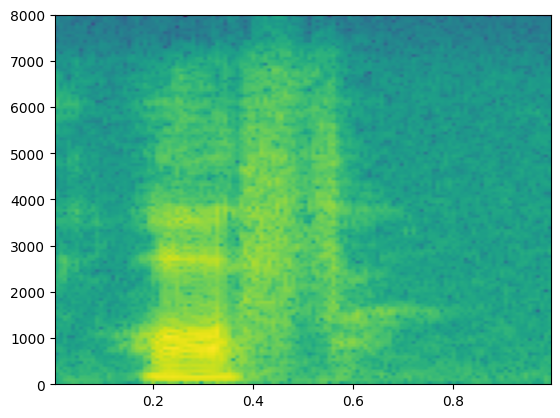

In [16]:
plt.specgram(audio.numpy(), Fs=16000)

In [119]:
import tensorflow as tf

class CNNAudioModel(tf.keras.Model):
    def __init__(self, num_classes, name=None):
        super().__init__(name=name)

        self.specLayer = tf.keras.layers.MelSpectrogram()
        self.cnnLayer = tf.keras.layers.Conv2D(filters=32,kernel_size=(3, 3),activation='relu')
        self.global_pool = tf.keras.layers.GlobalAveragePooling2D()
        self.denseLayer = tf.keras.layers.Dense(units=num_classes, activation='softmax')

    def call(self, x):
        x = self.specLayer(x)
        
        x = tf.expand_dims(x, -1)

        x = self.cnnLayer(x)
        x = self.global_pool(x)
        return self.denseLayer(x)

In [120]:
model = CNNAudioModel(len(labels))

In [ ]:
model(tf.convert_to_tensor())

<tf.Tensor: shape=(2, 12), dtype=float32, numpy=
array([[5.0992639e-05, 2.2145079e-08, 1.9890506e-07, 3.3610979e-17,
        1.2393492e-07, 1.5923657e-01, 5.7235047e-07, 1.6148084e-17,
        1.7019712e-16, 4.1822419e-01, 4.2245531e-01, 3.1954565e-05],
       [5.0992639e-05, 2.2145079e-08, 1.9890506e-07, 3.3610979e-17,
        1.2393492e-07, 1.5923657e-01, 5.7235047e-07, 1.6148084e-17,
        1.7019712e-16, 4.1822419e-01, 4.2245531e-01, 3.1954565e-05]],
      dtype=float32)>

In [121]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [107]:
def preprocess(audio, label):

    audio = tf.cast(audio, tf.float32)

    # force longueur 16000
    audio = audio[:16000]  # crop si trop long
    audio = tf.pad(audio, [[0, 16000 - tf.shape(audio)[0]]])  # pad si trop court

    return audio, label


BATCH_SIZE = 32

ds_train = ds_train.map(preprocess)
ds_test = ds_test.map(preprocess)

ds_train = ds_train.batch(BATCH_SIZE)
ds_test = ds_test.batch(BATCH_SIZE)

ds_train = ds_train.prefetch(tf.data.AUTOTUNE)
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)

In [108]:
for x, y in ds_train.take(1):
    print(x.shape, y.shape)

(32, 16000) (32,)


In [110]:
print(tf.data.experimental.cardinality(ds_train).numpy())

2673


In [122]:
history = model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=10
)

Epoch 1/10
2673/2673 ━━━━━━━━━━━━━━━━━━━━ 52s 19ms/step - accuracy: 0.6242 - loss: 1.8055 - val_accuracy: 0.0834 - val_loss: 3.0397
Epoch 2/10
2673/2673 ━━━━━━━━━━━━━━━━━━━━ 52s 19ms/step - accuracy: 0.6324 - loss: 1.5498 - val_accuracy: 0.0834 - val_loss: 3.1810
Epoch 3/10
2673/2673 ━━━━━━━━━━━━━━━━━━━━ 52s 19ms/step - accuracy: 0.6324 - loss: 1.5286 - val_accuracy: 0.0834 - val_loss: 3.0705
Epoch 4/10
 917/2673 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.6338 - loss: 1.5111

KeyboardInterrupt: 

In [123]:
for audio, label in ds_test.take(5): print(labels[model(audio).numpy().argmax()], "vs", labels[label])

IndexError: list index out of range

In [2]:
import torch

torch.cuda.is_available()

True

In [74]:
import torchaudio
data = torchaudio.datasets.SPEECHCOMMANDS(download=True, root="./")

In [84]:

data_train = torchaudio.datasets.SPEECHCOMMANDS(download=True, root="./", subset="training")
data_train.__len__()

84843

In [85]:

data_validation = torchaudio.datasets.SPEECHCOMMANDS(download=True, root="./", subset="validation")
data_validation.__len__()

9981

In [86]:

data_testing = torchaudio.datasets.SPEECHCOMMANDS(download=True, root="./", subset="testing")
data_testing.__len__()

11005

In [ ]:
data.__getitem__(10) # Waveform, Samplerate, Labl, SpeakerID, UtteranceNUMBER

(tensor([[ 0.0000e+00, -9.1553e-05, -3.0518e-05,  ...,  3.0518e-05,
          -1.2207e-04, -2.1362e-04]]),
 16000,
 'backward',
 '02ade946',
 4)

In [77]:
data.__len__()

105829

In [79]:
data.__getitem__(105828) # Waveform, Samplerate, Labl, SpeakerID, UtteranceNUMBER

(tensor([[-0.0010, -0.0009, -0.0012,  ..., -0.0006, -0.0013, -0.0009]]),
 16000,
 'zero',
 'fffcabd1',
 0)

"Yes", "No", "Up", "Down", "Left",
"Right", "On", "Off", "Stop", "Go", "Zero", "One", "Two", "Three", "Four",
"Five", "Six", "Seven", "Eight","Nine","Bed", "Bird", "Cat", "Dog", "Happy", "House", "Marvin", "Sheila",
"Tree", "Wow".

In [81]:
data.__doc__

'*Speech Commands* :cite:`speechcommandsv2` dataset.\n\n    Args:\n        root (str or Path): Path to the directory where the dataset is found or downloaded.\n        url (str, optional): The URL to download the dataset from,\n            or the type of the dataset to dowload.\n            Allowed type values are ``"speech_commands_v0.01"`` and ``"speech_commands_v0.02"``\n            (default: ``"speech_commands_v0.02"``)\n        folder_in_archive (str, optional):\n            The top-level directory of the dataset. (default: ``"SpeechCommands"``)\n        download (bool, optional):\n            Whether to download the dataset if it is not found at root path. (default: ``False``).\n        subset (str or None, optional):\n            Select a subset of the dataset [None, "training", "validation", "testing"]. None means\n            the whole dataset. "validation" and "testing" are defined in "validation_list.txt" and\n            "testing_list.txt", respectively, and "training" is t

In [16]:
import wave
import numpy as np
import matplotlib.pyplot as plt

s = wave.open("./SpeechCommands/speech_commands_v0.02/on/004ae714_nohash_0.wav")
signal = s.readframes(-1)
signal = np.frombuffer(signal, np.int16)

In [52]:
s.getnchannels()

1

Text(0.5, 1.0, 'on')

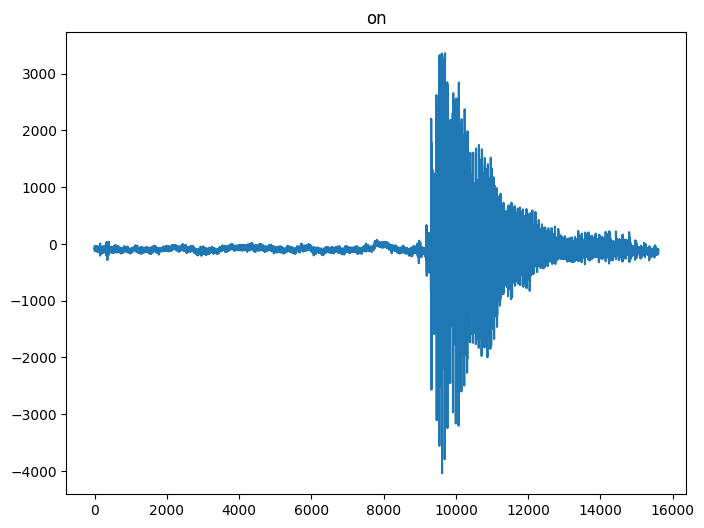

In [20]:
plt.figure(figsize=(8,6))
plt.plot(signal)
plt.title("on")

In [22]:
print(signal.shape)

(15604,)


In [27]:
np.frombuffer(wave.open("./SpeechCommands/speech_commands_v0.02/on/004ae714_nohash_1.wav").readframes(-1),np.int16).shape

(11889,)

Tous les fichiers audio n'on pas la même longueur

In [44]:
import torchaudio.transforms as T

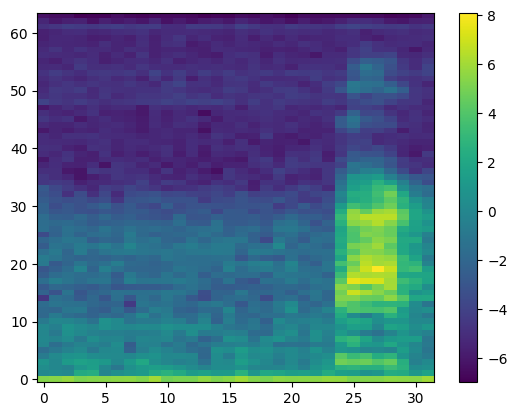

In [ ]:
transform = T.MelSpectrogram(n_fft=1024, sample_rate=16000, n_mels=64, hop_length=512)

item = data.__getitem__(0)

signal = item[0]
spectrogram = transform(signal)[0]

#Se rapproche de la perception humaine
#log_mel = torch.log(spectrogram + 1e-10)

plt.imshow(spectrogram.numpy(), origin="lower", aspect="auto", interpolation="nearest")
plt.colorbar()
plt.show()

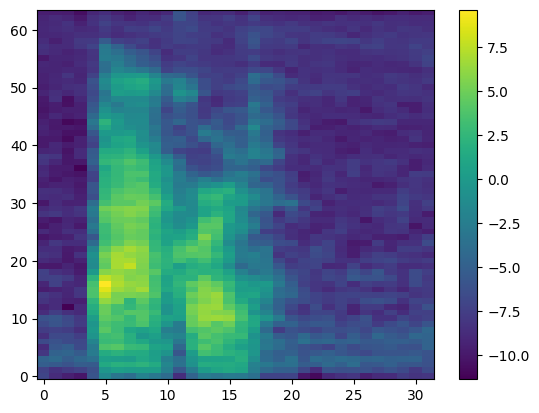

In [92]:
transform = T.MelSpectrogram(n_fft=1024, sample_rate=16000, n_mels=64, hop_length=512)

item = data.__getitem__(1)

signal = item[0]
spectrogram = transform(signal)[0]

#Se rapproche de la perception humaine
log_mel = torch.log(spectrogram + 1e-10)

plt.imshow(log_mel.numpy(), origin="lower", aspect="auto", interpolation="nearest")
plt.colorbar()
plt.show()

In [208]:
class CNNModuleTorch(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.spec = T.MelSpectrogram(n_fft=1024, sample_rate=16000, n_mels=64, hop_length=512)

        self.cnn = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(32, 64, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2)  
        )
        

        self.pool = torch.nn.AdaptiveAvgPool2d((4, 4)) 
        
        self.flatten = torch.nn.Flatten()
        
        self.dense = torch.nn.Linear(64 * 4 * 4, 35)

    def forward(self, x):
        x = self.spec(x)
        x = torch.log(x + 1e-10)
        
        #x = x.unsqueeze(1)

        x = self.cnn(x)
        x = self.pool(x)
        x = self.flatten(x)
        return self.dense(x)

In [195]:
model = CNNModuleTorch()
all_labels = [
    "backward", "bed", "bird", "cat", "dog", "down", "eight", "five", "follow", 
    "forward", "four", "go", "happy", "house", "learn", "left", "marvin", 
    "nine", "no", "off", "on", "one", "right", "seven", "sheila", "six", 
    "stop", "three", "tree", "two", "up", "visual", "wow", "yes", "zero"
]

In [201]:
len(all_labels)

35

In [ ]:
item = data.__getitem__(1)

print(all_labels[model(item[0]).argmax()].lower())
print(item[2])


sheila
backward


In [250]:
import torch.optim as optim
from torch.utils.data import DataLoader

# 1. Hyperparamètres
batch_size = 32
learning_rate = 0.001
epochs = 10
device = torch.device("cpu")

# 2. DataLoaders (indispensable pour l'entraînement par lots)
# On suppose que 'data' est votre dataset SpeechCommands
def pad_sequence(batch):
    target_len = 16000
    new_batch = []
    
    for waveform, sample_rate, label_str, speaker_id, utterance_number in batch:
        # On ajuste la taille du son
        current_len = waveform.shape[1]
        if current_len < target_len:
            waveform = torch.nn.functional.pad(waveform, (0, target_len - current_len))
        else:
            waveform = waveform[:, :target_len]

        # ATTENTION ICI : 
        # On a besoin d'un chiffre pour l'entraînement.
        # Si votre dataset est bien configuré, vous pouvez créer un dictionnaire 
        # pour transformer "follow" -> 0, "yes" -> 1, etc.
        # Mais souvent, SpeechCommands fournit déjà un ID. 
        # Si 'label_str' est le mot, utilisez une liste de référence :
        label_id = all_labels.index(label_str) 
        
        new_batch.append((waveform, label_id))

    waveforms = torch.stack([item[0] for item in new_batch])
    # Maintenant c'est une liste d'entiers, donc torch.tensor() fonctionnera !
    labels_tensor = torch.tensor([item[1] for item in new_batch])
    
    return waveforms, labels_tensor
    
    return waveforms, labels

# Utilisation dans le DataLoader
train_loader = DataLoader(
    data_train, 
    batch_size=32, 
    shuffle=True, 
    collate_fn=pad_sequence # <--- C'est ici que la magie opère
)

# 3. Initialisation
model = CNNModuleTorch().to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [252]:
# --- Paramètres de l'Early Stopping ---
patience = 5              # Nombre d'époques à attendre sans amélioration
best_loss = float('inf')  # On commence avec une perte infinie
trigger_times = 0         # Compteur de stagnation

model.train() 

for epoch in range(epochs):
    running_loss = 0.0
    
    for batch_idx, (waveforms, labels_batch) in enumerate(train_loader):
        waveforms = waveforms.to(device)
        labels_batch = labels_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(waveforms)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if batch_idx % 50 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

    # Calcul de la perte moyenne de l'époque
    epoch_loss = running_loss / len(train_loader)
    print(f"Fin de l'époque {epoch+1}, Loss moyenne: {epoch_loss:.4f}")

    # --- Logique de l'Early Stopping ---
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        trigger_times = 0
        # On sauvegarde le meilleur modèle trouvé jusqu'ici
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Nouveau meilleur modèle sauvegardé (Loss: {best_loss:.4f})")
    else:
        trigger_times += 1
        print(f"Pas d'amélioration. Compteur Early Stopping: {trigger_times}/{patience}")

        if trigger_times >= patience:
            print(f"Early Stopping déclenché ! Arrêt à l'époque {epoch+1}")
            break

Epoch 1/10 | Batch 0/2652 | Loss: 3.1477
Epoch 1/10 | Batch 50/2652 | Loss: 2.8596
Epoch 1/10 | Batch 100/2652 | Loss: 3.1969
Epoch 1/10 | Batch 150/2652 | Loss: 3.0747
Epoch 1/10 | Batch 200/2652 | Loss: 2.5383
Epoch 1/10 | Batch 250/2652 | Loss: 2.5789
Epoch 1/10 | Batch 300/2652 | Loss: 2.3860
Epoch 1/10 | Batch 350/2652 | Loss: 2.6688
Epoch 1/10 | Batch 400/2652 | Loss: 2.3124
Epoch 1/10 | Batch 450/2652 | Loss: 2.4254
Epoch 1/10 | Batch 500/2652 | Loss: 2.5312
Epoch 1/10 | Batch 550/2652 | Loss: 1.7958
Epoch 1/10 | Batch 600/2652 | Loss: 2.1025
Epoch 1/10 | Batch 650/2652 | Loss: 2.1023
Epoch 1/10 | Batch 700/2652 | Loss: 1.3288
Epoch 1/10 | Batch 750/2652 | Loss: 2.2653
Epoch 1/10 | Batch 800/2652 | Loss: 1.3893
Epoch 1/10 | Batch 850/2652 | Loss: 1.6178
Epoch 1/10 | Batch 900/2652 | Loss: 1.4620
Epoch 1/10 | Batch 950/2652 | Loss: 1.7223
Epoch 1/10 | Batch 1000/2652 | Loss: 1.4985
Epoch 1/10 | Batch 1050/2652 | Loss: 1.4082
Epoch 1/10 | Batch 1100/2652 | Loss: 1.6100
Epoch 1/10 

In [244]:
def resize(wave):
    target_len = 16000
    current_len = wave.shape[0]
    if current_len < target_len:
        diff = target_len - current_len
        wave = np.pad(wave, (0, diff), mode='constant')
    else:
        wave = wave[:target_len]

    return wave

(16000,)
(16000,)
on


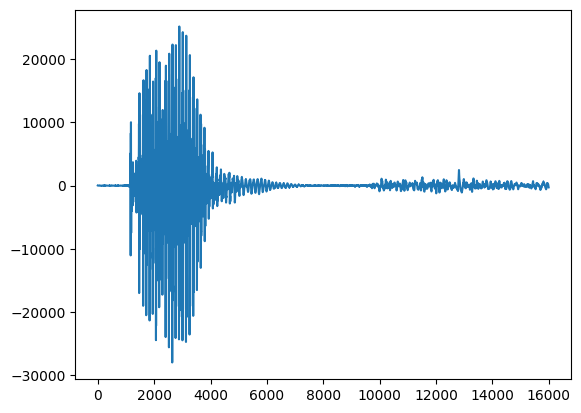

In [258]:
audio = np.frombuffer(wave.open("./SpeechCommands/speech_commands_v0.02/on/02ade946_nohash_4.wav").readframes(-1),np.int16)

print(audio.shape)

print(resize(audio).shape)

plt.plot(resize(audio))

audio_fp32 = resize(audio).astype(np.float32) / 32768.0

input_tensor = torch.from_numpy(audio_fp32).unsqueeze(0).to(device)
input_tensor = input_tensor.unsqueeze(0)


model.eval()
with torch.no_grad():
    print(all_labels[model(input_tensor).argmax()])

(98304,)
(16000,)
seven


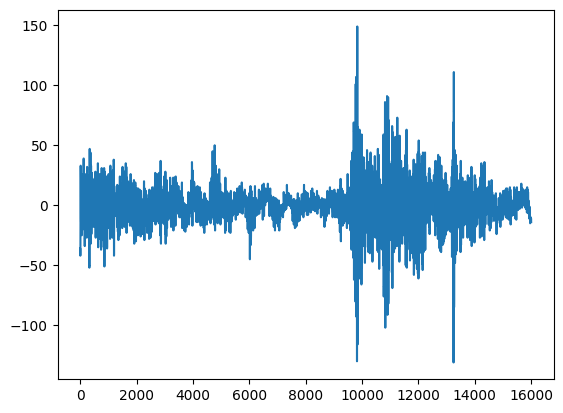

In [ ]:
audio = np.frombuffer(wave.open("./record.wav").readframes(-1),np.int16)

print(audio.shape)

print(resize(audio).shape)

plt.plot(resize(audio))

audio_fp32 = resize(audio).astype(np.float32) / 32768.0

input_tensor = torch.from_numpy(audio_fp32).unsqueeze(0).to(device)
input_tensor = input_tensor.unsqueeze(0)


model.eval()
with torch.no_grad():res.argmax(dim=1).item(
    print(all_labels[model(input_tensor).argmax(dim=1)])

In [288]:
data_testing.__getitem__(i)[0]


tensor([[-0.0015, -0.0024, -0.0029,  ..., -0.0012, -0.0010, -0.0027]])

In [314]:
correct = 0

model.eval()

with torch.no_grad():

    for i in range(len(waveforms)):

        x = waveforms[i].unsqueeze(0).to(device)

        outputs = model(x)

        pred = outputs.argmax(dim=1).item()

        print(all_labels[pred])
        print(all_labels[labels[i].item()])

        if pred == labels[i].item():
            correct += 1

print("Accuracy :", correct / len(waveforms) * 100, "%")

forward
one
four
go
seven
eight
stop
forward
nine
backward
marvin
stop
go
go
seven
bird
follow
one
two
happy
tree
on
Accuracy : 9.090909090909092 %


In [ ]:
class CNNModuleDEBUG(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.spec = T.MelSpectrogram(n_fft=1024, sample_rate=16000, n_mels=64, hop_length=512)

        self.cnn = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(32, 64, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2)  res.argmax(dim=1).item(
        )
        

        self.pool = torch.nn.AdaptiveAvgPool2d((4, 4)) 
        
        self.flatten = torch.nn.Flatten()
        
        self.dense = torch.nn.Linear(64 * 4 * 4, 35)

    def forward(self, x):
        x = self.spec(x)
        x = torch.log(x + 1e-10)

        if len(x.shape) <= 3:
            x = x.unsqueeze(0)

        x = self.cnn(x)

        x = self.pool(x)
        x = self.flatten(x)
        return self.dense(x)

In [385]:
model_debug = CNNModuleDEBUG().to(device)

model_debug.load_state_dict(torch.load("./best_model.pth", weights_only=True))

criterion_debug = torch.nn.CrossEntropyLoss()
optimizer_debug = optim.Adam(model.parameters(), lr=learning_rate)

In [390]:
elem = data_train.__getitem__(0)

print(elem)

softmax = torch.nn.Softmax()
output = model_debug(elem[0])
res = softmax(output)
print(res)
print(res.argmax(dim=1).item())
print(all_labels.index(elem[2]))

print(res.argmax(dim=1).item() == all_labels.index(elem[2]))

(tensor([[-0.0658, -0.0709, -0.0753,  ..., -0.0700, -0.0731, -0.0704]]), 16000, 'backward', '0165e0e8', 0)
tensor([[8.9653e-02, 1.0610e-03, 2.1030e-02, 3.0401e-01, 1.9523e-03, 1.0304e-01,
         3.3294e-05, 2.4234e-01, 2.6271e-04, 1.8482e-03, 1.5929e-04, 1.9724e-04,
         7.9413e-03, 7.1848e-04, 6.4179e-03, 1.9375e-02, 1.3586e-02, 8.8354e-03,
         1.0011e-05, 1.0731e-03, 1.3647e-02, 1.2997e-03, 8.3502e-02, 3.4497e-03,
         1.9412e-05, 6.3528e-07, 4.5045e-02, 8.7586e-04, 3.0359e-06, 1.7837e-06,
         2.8000e-02, 3.2240e-06, 5.8618e-04, 2.5701e-05, 1.1058e-06]],
       grad_fn=<SoftmaxBackward0>)
3
0
False


In [393]:
correct = 0

for i in range(0,1000):
    elem = data_train.__getitem__(i)

    softmax = torch.nn.Softmax()
    output = model_debug(elem[0])
    res = softmax(output)

    if res.argmax(dim=1).item() == all_labels.index(elem[2]): correct = correct + 1

print(correct / 1000 * 100)

87.4


In [ ]:
audio = np.frombuffer(wave.open("./perso.wav").readframes(-1),np.int16)
audio = audio[:16000]
audio = torch.Tensor(audio)



audio = audio.unsqueeze(0)

print(audio.shape)

softmax = torch.nn.Softmax()
output = model_debug(audio)
res = softmax(output)
print(res)
print(all_labels[res.argmax()])
output = m(audio)
    res = softmax(output)
    print(res)
    print(all_labels[res.argmax()])

torch.Size([1, 16000])
tensor([[4.9961e-21, 1.6492e-18, 1.6431e-06, 3.3380e-14, 1.0131e-09, 1.7450e-03,
         8.6850e-20, 3.7173e-11, 9.3354e-17, 6.3491e-12, 2.2979e-10, 9.9825e-01,
         1.9487e-17, 4.4158e-12, 3.2328e-06, 3.8625e-22, 8.9686e-20, 5.6216e-11,
         1.1796e-09, 9.5493e-07, 2.0099e-10, 2.6257e-16, 7.4398e-15, 1.2209e-20,
         5.6959e-22, 1.3371e-26, 1.3643e-23, 2.2115e-12, 6.6426e-14, 4.4290e-14,
         6.0387e-13, 5.8947e-30, 2.1504e-08, 1.7998e-16, 6.7310e-20]],
       grad_fn=<SoftmaxBackward0>)
go


In [414]:
audio = np.frombuffer(wave.open("./record.wav").readframes(-1),np.int16)
audio = audio[:16000]
audio = torch.Tensor(audio)

audio = audio.unsqueeze(0)

print(audio.shape)

softmax = torch.nn.Softmax(dim=1)
output = model_debug(audio)
res = softmax(output)
print(res)
print(all_labels[res.argmax()])


torch.Size([1, 16000])
tensor([[2.6980e-25, 1.4959e-17, 8.5695e-13, 5.4769e-19, 3.1106e-06, 3.9590e-05,
         4.4173e-23, 3.3472e-13, 4.9450e-11, 3.2915e-13, 5.6155e-05, 4.6964e-08,
         2.6361e-29, 4.7894e-12, 3.2065e-16, 5.6508e-31, 3.9899e-23, 6.2849e-18,
         4.6954e-14, 9.9990e-01, 1.8674e-08, 5.0208e-17, 1.3611e-22, 2.0821e-14,
         5.1592e-23, 5.2479e-20, 2.4345e-16, 2.9105e-23, 1.4001e-27, 5.7698e-23,
         3.5768e-15, 1.2109e-39, 5.2797e-10, 8.2524e-16, 4.8611e-22]],
       grad_fn=<SoftmaxBackward0>)
off


In [411]:
def eval_wav_file(m, f):
    audio = np.frombuffer(wave.open(f).readframes(-1),np.int16)
    audio = audio[:16000]
    audio = torch.Tensor(audio)

    audio = audio.unsqueeze(0)

    print(audio.shape)

    softmax = torch.nn.Softmax(dim=1)
    with torch.no_grad():
        output = m(audio)
        res = softmax(output)
        
    print(res)
    print(all_labels[res.argmax()])

In [412]:
eval_wav_file(model_debug, "./record.wav")

torch.Size([1, 16000])
tensor([[2.6980e-25, 1.4959e-17, 8.5695e-13, 5.4769e-19, 3.1106e-06, 3.9590e-05,
         4.4173e-23, 3.3472e-13, 4.9450e-11, 3.2915e-13, 5.6155e-05, 4.6964e-08,
         2.6361e-29, 4.7894e-12, 3.2065e-16, 5.6508e-31, 3.9899e-23, 6.2849e-18,
         4.6954e-14, 9.9990e-01, 1.8674e-08, 5.0208e-17, 1.3611e-22, 2.0821e-14,
         5.1592e-23, 5.2479e-20, 2.4345e-16, 2.9105e-23, 1.4001e-27, 5.7698e-23,
         3.5768e-15, 1.2109e-39, 5.2797e-10, 8.2524e-16, 4.8611e-22]])
off


In [415]:
correct = 0

for i in range(0,1000):
    elem = data_testing.__getitem__(i)

    softmax = torch.nn.Softmax()
    output = model_debug(elem[0])
    res = softmax(output)

    if res.argmax(dim=1).item() == all_labels.index(elem[2]): correct = correct + 1

print(correct / 1000 * 100)

/home/stcaillou/UTT/IA02/Projet/.venv/lib/python3.11/site-packages/torch/nn/modules/module.py:1778: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


82.5
